In [2]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(reshape2)
library(scales)
library(gridExtra)
library(biomaRt)
library(patchwork)
#library(ComplexHeatmap)
library(circlize)
#library(ChIPseeker)
library(dplyr)
library(ggrastr)
library(GenomicRanges)

In [3]:
saf_to_granges <- function(saf){
   library(GenomicRanges)
   gr <- with(saf, GRanges(Chr, IRanges(Start, End), id=Geneid, strand=Strand))
   return(gr)
}

In [4]:
h3k9ac.data = read.table("../results//a3_h3k9ac_featurecounts.txt", header=1)
h3k9ac.peak.info = h3k9ac.data[,1:6]
h3k9ac.data = h3k9ac.data[,7:dim(h3k9ac.data)[2]]
rownames(h3k9ac.data) = h3k9ac.peak.info$Geneid

colnames(h3k9ac.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(h3k9ac.data)))
head(h3k9ac.data)

,cloneA3__HU__H3K9me2__rep1,cloneA3__HU__H3K9me2__rep2,cloneA3__HU__H3K9me2__rep3,cloneA3__Unt__H3K9me2__rep1,cloneA3__Unt__H3K9me2__rep2,cloneA3__Unt__H3K9me2__rep3,cloneA3__Unt_pA_Mnase__H3K9me2__rep1,cloneA3__HU__H3K9ac__rep1,cloneA3__HU__H3K9ac__rep2,cloneA3__Unt__H3K9ac__rep1,cloneA3__Unt__H3K9ac__rep2,cloneA3__Unt__H3K9ac__rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9ac_peak1,4,9,3,7,8,6,8,164,143,105,106,144
h3k9ac_peak2,0,3,1,4,0,1,0,12,16,8,7,9
h3k9ac_peak3,3,1,5,1,3,2,1,3,4,2,5,4
h3k9ac_peak4,1,3,1,2,1,0,7,39,48,22,44,49
h3k9ac_peak5,0,0,1,0,1,0,0,6,14,5,6,10
h3k9ac_peak6,1,1,3,2,0,0,6,17,7,4,8,11


In [5]:
h3k9me2.data = read.table("../results//a3_h3k9me2_featurecounts.txt", header=1)
h3k9me2.peak.info = h3k9me2.data[,1:6]
h3k9me2.data = h3k9me2.data[,7:dim(h3k9me2.data)[2]]
rownames(h3k9me2.data) = h3k9me2.peak.info$Geneid

colnames(h3k9me2.data) = gsub("...bowtie2_bam.", "", 
                   gsub("_aligned_sorted_noblacklist.bam", "", colnames(h3k9me2.data)))
head(h3k9me2.data)

,cloneA3__HU__H3K9me2__rep1,cloneA3__HU__H3K9me2__rep2,cloneA3__HU__H3K9me2__rep3,cloneA3__Unt__H3K9me2__rep1,cloneA3__Unt__H3K9me2__rep2,cloneA3__Unt__H3K9me2__rep3,cloneA3__Unt_pA_Mnase__H3K9me2__rep1,cloneA3__HU__H3K9ac__rep1,cloneA3__HU__H3K9ac__rep2,cloneA3__Unt__H3K9ac__rep1,cloneA3__Unt__H3K9ac__rep2,cloneA3__Unt__H3K9ac__rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
h3k9me2_peak1,13,19,29,35,36,21,15,14,13,11,13,4
h3k9me2_peak2,4,7,11,12,7,1,2,13,11,10,9,13
h3k9me2_peak3,1,2,0,5,2,1,3,3,1,0,1,3
h3k9me2_peak4,0,1,5,6,3,5,0,1,4,0,1,0
h3k9me2_peak5,2,8,6,5,4,6,5,1,3,0,1,3
h3k9me2_peak6,76,59,59,77,105,72,35,32,43,27,25,39


In [19]:
colnames(h3k9me2.data)

[1] "cloneA3__HU__H3K9me2__rep1"          
 [2] "cloneA3__HU__H3K9me2__rep2"          
 [3] "cloneA3__HU__H3K9me2__rep3"          
 [4] "cloneA3__Unt__H3K9me2__rep1"         
 [5] "cloneA3__Unt__H3K9me2__rep2"         
 [6] "cloneA3__Unt__H3K9me2__rep3"         
 [7] "cloneA3__Unt_pA_Mnase__H3K9me2__rep1"
 [8] "cloneA3__HU__H3K9ac__rep1"           
 [9] "cloneA3__HU__H3K9ac__rep2"           
[10] "cloneA3__Unt__H3K9ac__rep1"          
[11] "cloneA3__Unt__H3K9ac__rep2"          
[12] "cloneA3__Unt__H3K9ac__rep3"

In [20]:
h3k9ac.cr = list(h3k9ac.data[,8:12], h3k9me2.data[,8:12])
names(h3k9ac.cr) = c("h3k9ac.peaks", "h3k9me2.peaks")

h3k9me2.cr = list(h3k9ac.data[,1:6], h3k9me2.data[,1:6])
names(h3k9me2.cr) = c("h3k9ac.peaks", "h3k9me2.peaks")

## edgeR

In [6]:
library.sizes = read.csv("../results/mapping_results.csv")
rownames(library.sizes) = library.sizes$file
head(library.sizes)

,file,human_reads,human_alignment_pct,mouse_reads,mouse_alignment_pct,human_mouse_ratio
,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>
clone32__HU__G9a__rep1,clone32__HU__G9a__rep1,14589134,95.94,360181,58.37,0.4050501
clone32__HU__G9a__rep2,clone32__HU__G9a__rep2,13622212,95.78,389288,64.87,0.3499263
clone32__HU__G9a__rep3,clone32__HU__G9a__rep3,11231840,96.29,272257,62.93,0.4125455
clone32__HU__H3K27ac__rep1,clone32__HU__H3K27ac__rep1,14838602,93.31,858552,80.65,0.1728329
clone32__HU__H3K27ac__rep2,clone32__HU__H3K27ac__rep2,17389525,93.83,927334,81.16,0.1875217
clone32__HU__H3K27ac__rep3,clone32__HU__H3K27ac__rep3,17018041,94.25,822554,79.27,0.2068927


In [10]:
get_fit = function(data, n=1, to_drop=F, hu_samples=3, norm_to_mouse=F) {
    #print(library.sizes[colnames(data),])
    
    libsz = library.sizes[colnames(data),]$human_reads
    print(libsz)
    if(norm_to_mouse) {
        rt = library.sizes[colnames(data),]$human_mouse_ratio
        libsz = libsz * max(rt)/rt  # scale the library sizes by human to mouse ratio (the higher the ratio the lower the effective library size)
    }
    print(libsz)
    d0 <- DGEList(data, lib.size = libsz)
    #d0 <- calcNormFactors(d0, method="TMM")
    if (to_drop) {
        drop <- which(apply(cpm(d0), 1, max) < n)
        d0 <- d0[-drop,] 
    }
    print(dim(d0)) # number of genes left

    # conditions for differential peak calling
    conds = c(rep("HU",hu_samples),rep("unt",3))
    print(conds)

    # normalize
    mm <- model.matrix(~0 + conds)
    y <- voom(d0, mm, plot = T)
    fit <- lmFit(y, mm)
    #head(coef(fit))

    return(list(fit, conds, y$E))
}

# get differentially accessible peaks for each condition
process_res = function(fit, contr) {
    tmp <- contrasts.fit(fit, contr)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    return(res)
}

[1] 16949473 18846333 17899462 15769461 16248388 13627993
[1] 17175627 20415768 23519005 17827031 18219629 13627993
[1] 138516      6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"
[1] 18472638 18581627 13662817 16699264 17487132
[1] 29205907 27920692 14882005 16699264 18423239
[1] 37740     5
[1] "HU"  "HU"  "unt" "unt" "unt"


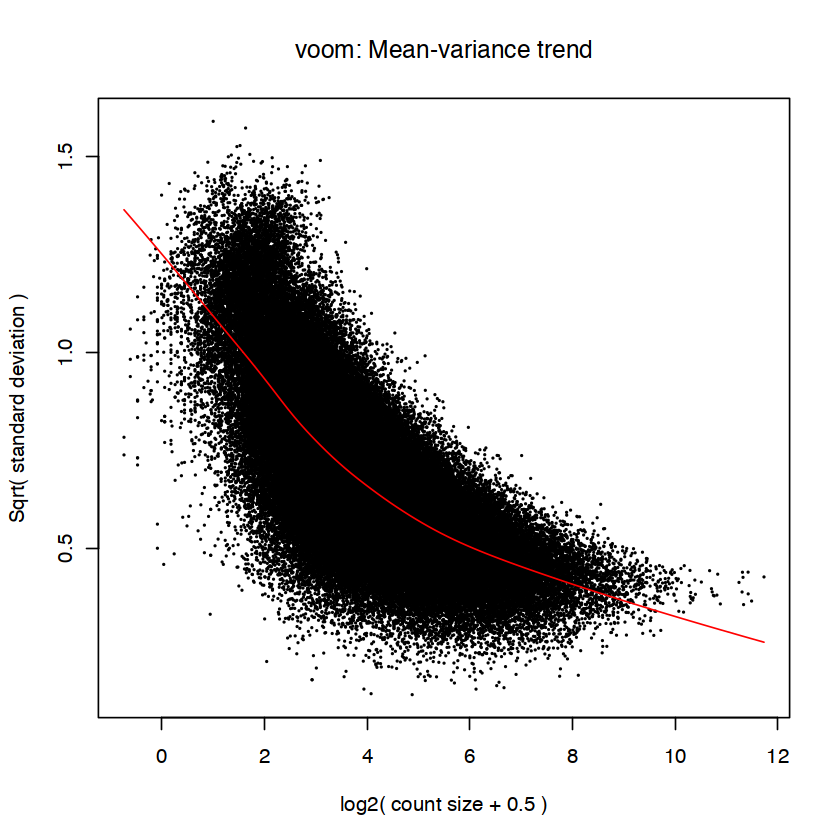

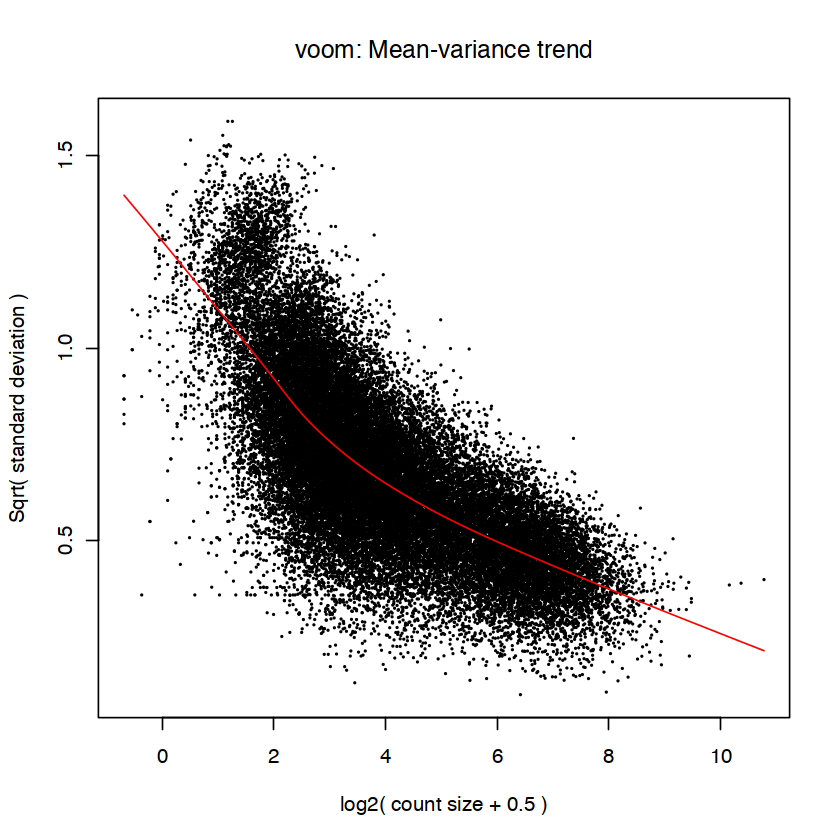

In [21]:
#Normalized to mouse
h3k9me2.k9me2peaks.ms = get_fit(h3k9me2.cr$h3k9me2.peaks, norm_to_mouse=T, hu_samples=3)
h3k9ac.k9acpeaks.ms = get_fit(h3k9ac.cr$h3k9ac.peaks, norm_to_mouse=T, hu_samples=2)

In [22]:
#Norm to mouse
h3k9me2.k9me2peaks.ms.dep = process_res(h3k9me2.k9me2peaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.k9me2peaks.ms[[1]]))))
h3k9ac.k9acpeaks.ms.dep = process_res(h3k9ac.k9acpeaks.ms[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9ac.k9acpeaks.ms[[1]]))))

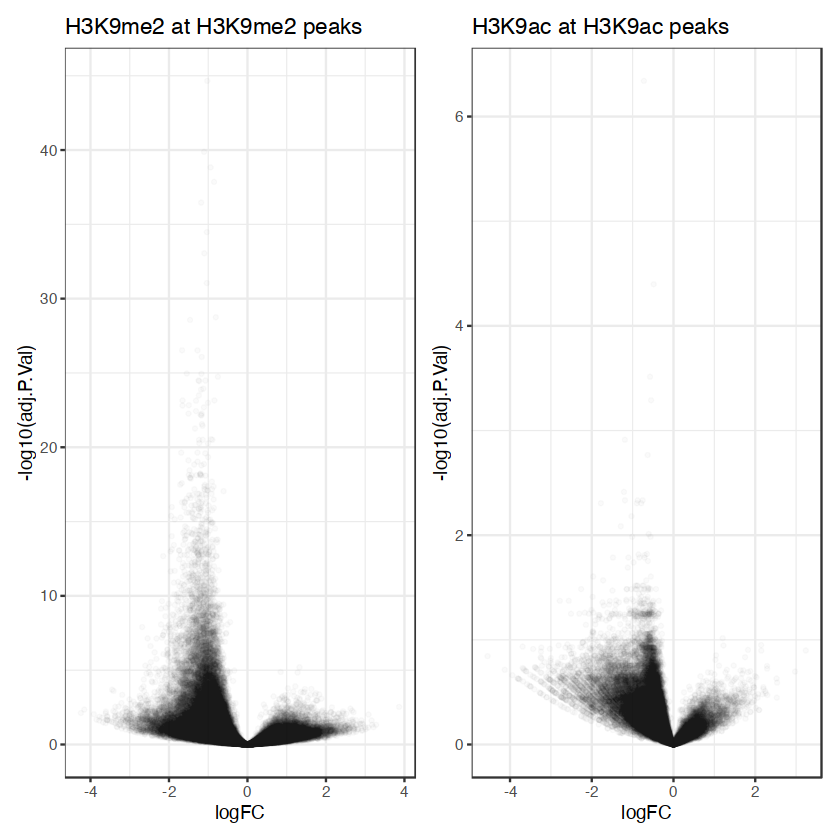

In [23]:
#Norm to mouse
#Note: set FDR at 0.1 instead of 0.05 to allow WIZ to have some differential peaks
#I think the norm to mouse creates higher variance in some of the samples

g1 = ggplot(h3k9me2.k9me2peaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at H3K9me2 peaks")
g2 = ggplot(h3k9ac.k9acpeaks.ms.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9ac at H3K9ac peaks")
g1 + g2

ggsave("../results//251203_volcanoplots_a3_mouse_norm.pdf", width=6, height=3)

[1] 16949473 18846333 17899462 15769461 16248388 13627993
[1] 16949473 18846333 17899462 15769461 16248388 13627993
[1] 138516      6
[1] "HU"  "HU"  "HU"  "unt" "unt" "unt"
[1] 18472638 18581627 13662817 16699264 17487132
[1] 18472638 18581627 13662817 16699264 17487132
[1] 37740     5
[1] "HU"  "HU"  "unt" "unt" "unt"


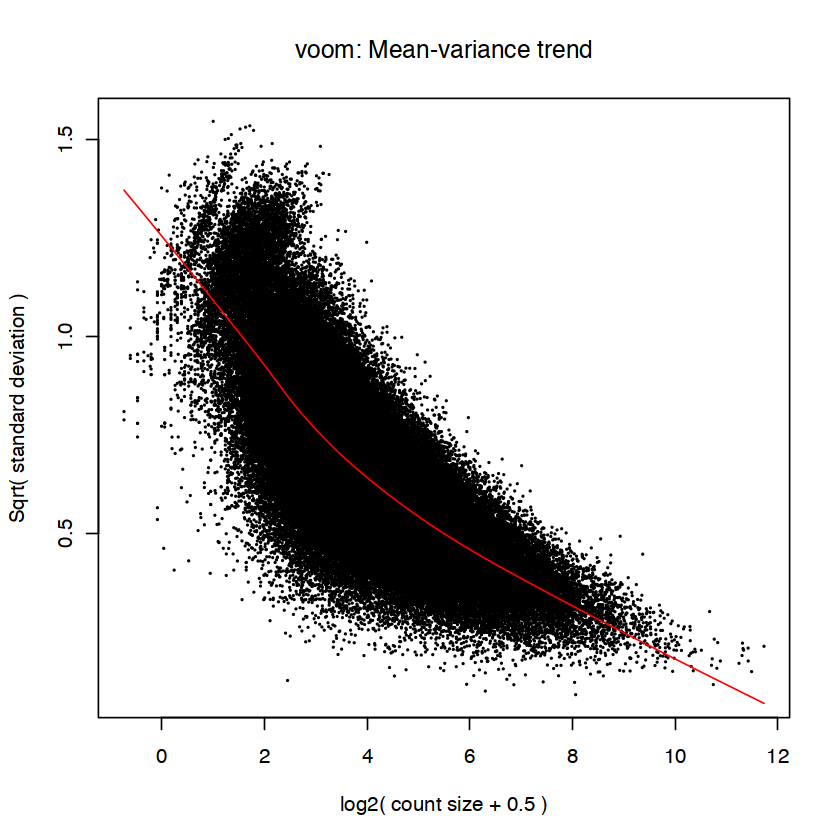

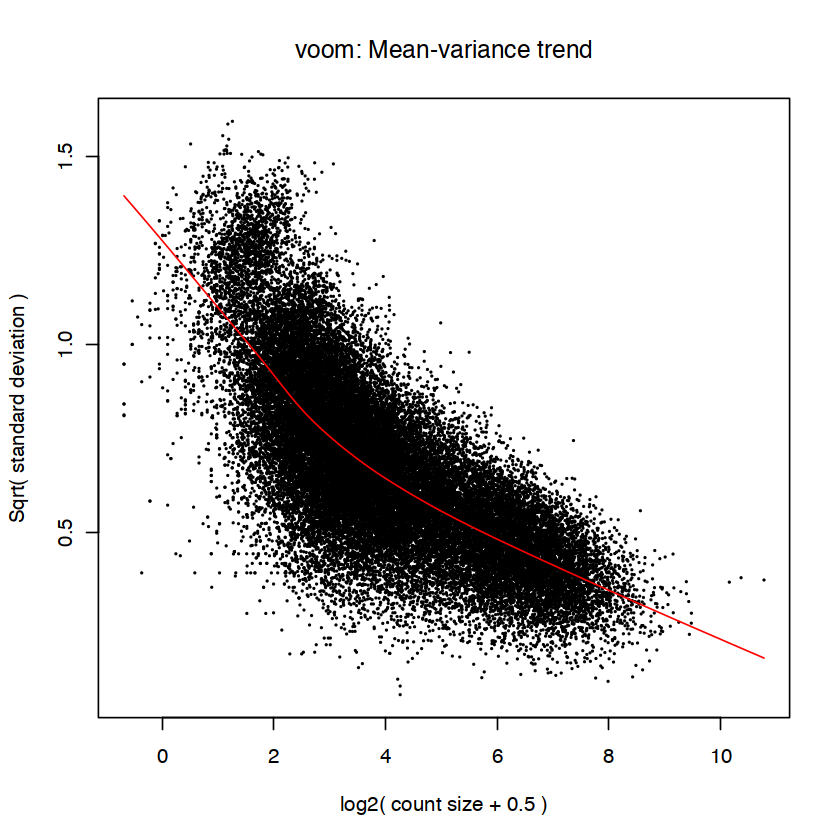

In [27]:
#Non norm to mouse
h3k9me2.k9me2peaks = get_fit(h3k9me2.cr$h3k9me2.peaks, norm_to_mouse=F, hu_samples=3)
h3k9ac.k9acpeaks = get_fit(h3k9ac.cr$h3k9ac.peaks, norm_to_mouse=F, hu_samples=2)
                           
#Norm to mouse
h3k9me2.k9me2peaks.dep = process_res(h3k9me2.k9me2peaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9me2.k9me2peaks[[1]]))))
h3k9ac.k9acpeaks.dep = process_res(h3k9ac.k9acpeaks[[1]], makeContrasts("condsHU-condsunt", levels = colnames(coef(h3k9ac.k9acpeaks[[1]]))))

In [29]:
dim(subset(h3k9me2.k9me2peaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9me2.k9me2peaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))
dim(subset(h3k9ac.k9acpeaks.ms.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9ac.k9acpeaks.ms.dep, logFC > 0.5 & adj.P.Val < 0.1))

[1] 20654     6

[1] 1922    6

[1] 347   6

[1] 1 6

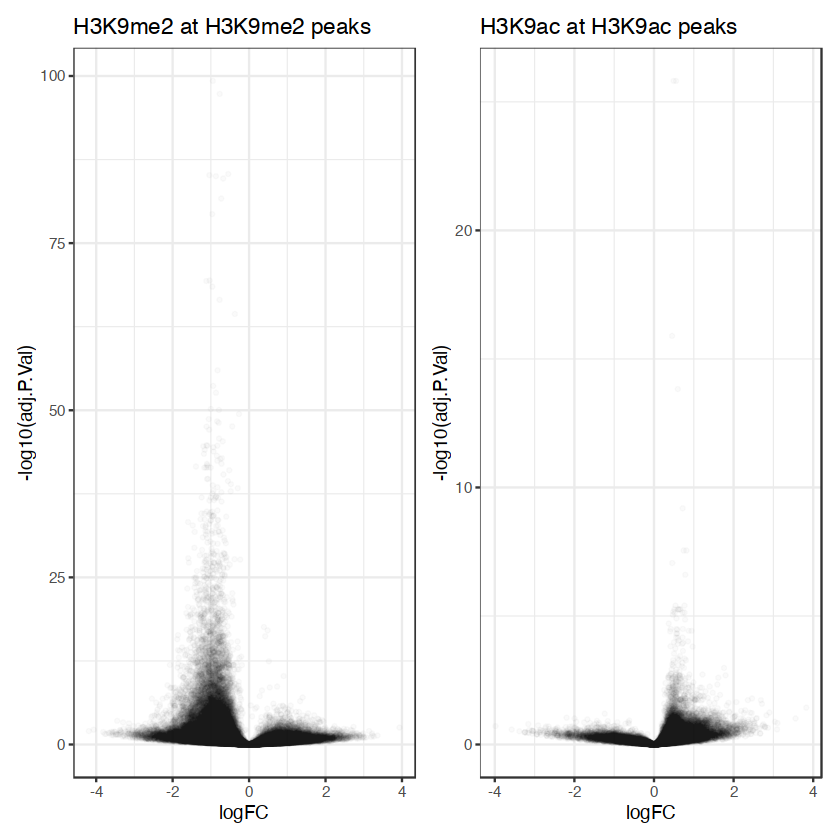

In [28]:
#Norm to mouse
#Note: set FDR at 0.1 instead of 0.05 to allow WIZ to have some differential peaks
#I think the norm to mouse creates higher variance in some of the samples

g1 = ggplot(h3k9me2.k9me2peaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9me2 at H3K9me2 peaks")
g2 = ggplot(h3k9ac.k9acpeaks.dep, aes(x=logFC, y=-log10(adj.P.Val))) + 
rasterize(geom_point(alpha=0.02, size=1), dpi=300) + theme_bw() + ggtitle("H3K9ac at H3K9ac peaks")
g1 + g2

ggsave("../results//251203_volcanoplots_a3_mouse.pdf", width=6, height=3)

In [30]:
dim(subset(h3k9me2.k9me2peaks.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9me2.k9me2peaks.dep, logFC > 0.5 & adj.P.Val < 0.1))
dim(subset(h3k9ac.k9acpeaks.dep, logFC < -0.5 & adj.P.Val < 0.1))
dim(subset(h3k9ac.k9acpeaks.dep, logFC > 0.5 & adj.P.Val < 0.1))

[1] 19080     6

[1] 3182    6

[1] 3 6

[1] 640   6